## Assignment Linear Models and Unsupervised Learning ##

In this jupyter notebook we will work with the `Student_performance_data.csv` dataset.


This dataset contains comprehensive information on 2392 high school students, detailing their demographics, study habits, parental involvement, extracurricular activities, and academic performance. The target variable, GradeClass, classifies students' grades into distinct categories.

**Info on available variables**

*   StudentID: A unique identifier assigned to each student (1001 to 3392).
*   Age: The age of the students ranges from 15 to 18 years.
*   Gender: Gender of the students, where 0 represents Male and 1 represents Female.
*   Ethnicity: The ethnicity of the students, coded as follows:
  *   0: Caucasian
  *   1: African American
  *   2: Asian
  *   3: Other
*   ParentalEducation: The education level of the parents, coded as follows:
  *   0: None
  *   1: High School
  *   2: Some College
  *   3: Bachelor's
  *   4: Higher
*   StudyTimeWeekly: Weekly study time in hours, ranging from 0 to 20.
*   Absences: Number of absences during the school year, ranging from 0 to 30.
*   Tutoring: Tutoring status, where 0 indicates No and 1 indicates Yes.
*   ParentalSupport: The level of parental support, coded as follows:
  *   0: None
  *   1: Low
  *   2: Moderate
  *   3: High
  *   4: Very High
*   Extracurricular: Participation in extracurricular activities, where 0 indicates No and 1 indicates Yes.
*   Sports: Participation in sports, where 0 indicates No and 1 indicates Yes.
*   Music: Participation in music activities, where 0 indicates No and 1 indicates Yes.
*   Volunteering: Participation in volunteering, where 0 indicates No and 1 indicates Yes.
*   GPA: Grade Point Average on a scale from 2.0 to 4.0, influenced by study habits, parental involvement, and extracurricular activities.

**Target Variable:** Grade Class
*   GradeClass: Classification of students' grades based on GPA:
  *   0: 'A' (GPA >= 3.5)
  *   1: 'B' (3.0 <= GPA < 3.5)
  *   2: 'C' (2.5 <= GPA < 3.0)
  *   3: 'D' (2.0 <= GPA < 2.5)
  *   4: 'F' (GPA < 2.0)

# Part 1: Data loading and preprocessing

In [126]:
# Import standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

1. Read the file 'Student_performance_data.csv' (available at 'https://raw.githubusercontent.com/iochoa/ml-datasets/main/Student_performance_data.csv')and load it into a pandas datafram called 'df' (1 point)

In [127]:
# Read the data (.csv file)
df = pd.read_csv("https://raw.githubusercontent.com/iochoa/ml-datasets/main/Student_performance_data.csv")

2. Extract basic info from the dataset (number of samples; number of columns; type of each column; presence of N/A or null values, etc.) (2 point)


In [128]:
df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


In [129]:
samples, columns = df.shape
print("Samples:", samples)
print("Columns:", columns)

Samples: 2392
Columns: 15


In [130]:
print("Null counts:")

display(df.isnull().sum())

print("Total null values: ", df.isnull().sum().sum())

Null counts:


StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64

Total null values:  0


In [131]:
print("Column Types:")
df.dtypes

Column Types:


StudentID              int64
Age                    int64
Gender                 int64
Ethnicity              int64
ParentalEducation      int64
StudyTimeWeekly      float64
Absences               int64
Tutoring               int64
ParentalSupport        int64
Extracurricular        int64
Sports                 int64
Music                  int64
Volunteering           int64
GPA                  float64
GradeClass           float64
dtype: object

In [132]:
print("Numerical Information:")
df.describe()

Numerical Information:


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
count,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000
mean,2196.500000,16.468645,0.510870,0.877508,1.746237,9.771992,14.541388,0.301421,2.122074,0.383361,0.303512,0.196906,0.157191,1.906186,2.983696
std,690.655244,1.123798,0.499986,1.028476,1.000411,5.652774,8.467417,0.458971,1.122813,0.486307,0.459870,0.397744,0.364057,0.915156,1.233908
min,1001.000000,15.000000,0.000000,0.000000,0.000000,0.001057,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1598.750000,15.000000,0.000000,0.000000,1.000000,5.043079,7.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.174803,2.000000
50%,2196.500000,16.000000,1.000000,0.000000,2.000000,9.705363,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.893393,4.000000
75%,2794.250000,17.000000,1.000000,2.000000,2.000000,14.408410,22.000000,1.000000,3.000000,1.000000,1.000000,0.000000,0.000000,2.622216,4.000000
max,3392.000000,18.000000,1.000000,3.000000,4.000000,19.978094,29.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,4.000000,4.000000


3. Remove column 'StudentID' since it does not add any useful information  (1 point)

In [133]:
df = df.drop(columns="StudentID", axis=1)
df

,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2387,18,1,0,3,10.680555,2,0,4,1,0,0,0,3.455509,0.0
2388,17,0,0,1,7.583217,4,1,4,0,1,0,0,3.279150,4.0
2389,16,1,0,2,6.805500,20,0,2,0,0,0,1,1.142333,2.0
2390,16,1,1,0,12.416653,17,0,2,0,1,1,0,1.803297,1.0


5. Let's visualize the `GradeClass` distribution in a bar plot, showing the number of instances for each value in `GradeClass`.

What is the most common value for `GradeClass`?  (3 point)


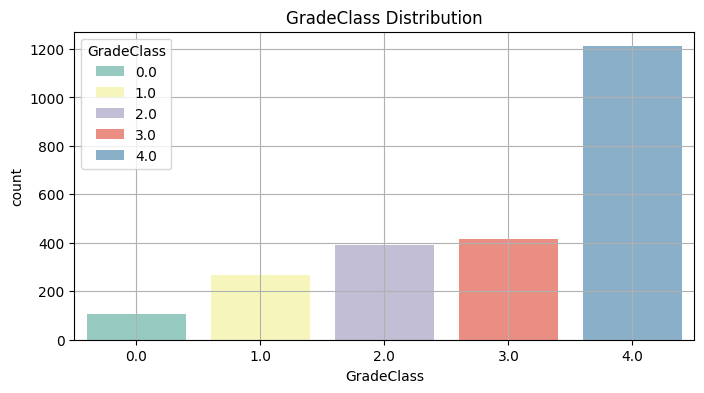

In [134]:
fig = plt.figure(figsize=(8,4))
sns.countplot(data=df, x="GradeClass", hue="GradeClass", palette="Set3")
plt.title("GradeClass Distribution")
plt.grid()

6. Split the data into `x` and `y`; with `y` being the column 'GradeClass'; and do a train/test split with a 80/20 ratio, using `random_state=42`  (1 point)

In [135]:
X = df.iloc[:, df.columns!="GradeClass"]
y = df.iloc[:, df.columns=="GradeClass"]

In [136]:
from sklearn.model_selection import train_test_split 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

7. Normalize the input variables with a Min-Max scaler, for both `x_train` and `x_test`; and plot a histogram of all scaled variables to make sure they are in the range `0:1` (Hint: you may want to convert x_train to a pandas dataframe first)  (3 point)

In [137]:
from sklearn.preprocessing import MinMaxScaler 
import pandas as pd

min_max_scaler = MinMaxScaler(feature_range=(0, 1))

In [138]:
X_train_scaled = min_max_scaler.fit_transform(X_train) # fit and transform train set
X_test_scaled = min_max_scaler.transform(X_test) # only transform test set

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

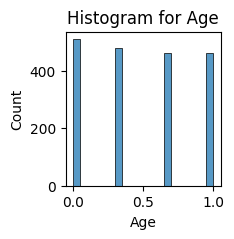

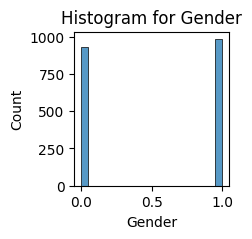

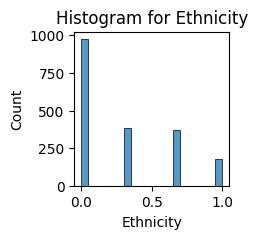

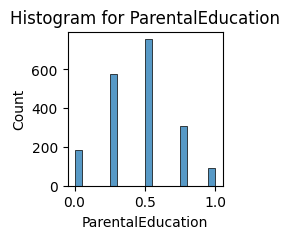

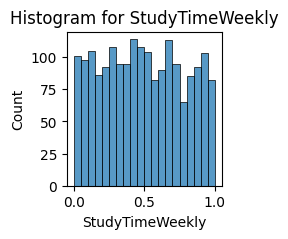

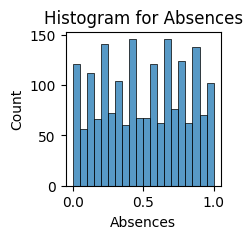

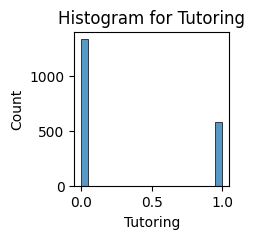

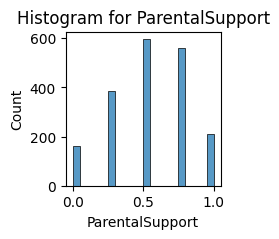

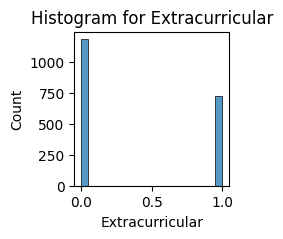

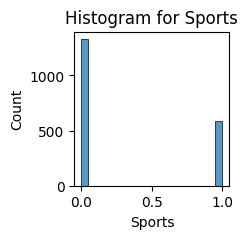

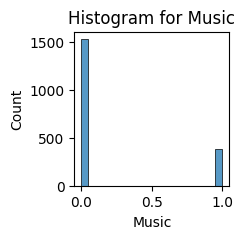

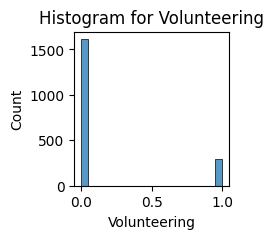

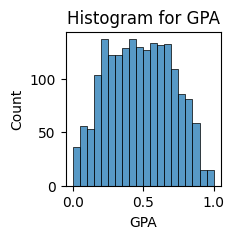

In [139]:
import seaborn as sns
import matplotlib.pyplot as plt

# iterate over each column
for column in X_train.columns:
    fig = plt.figure(figsize=(2,2)) # make the histograms smaller
    sns.histplot(data=X_train_scaled, x=column, bins=20)
    plt.title(f"Histogram for {column}")
    plt.show()



# Part 2: Supervised learning

We will now compare the performance of a logistic (softmax) regressor to predict the GradeClass and that of a liner regression model

1. Train a Logistic Regression model and a Linear Regression model (both with default parameters) on the scaled train set to predict the `GradeClass`  (2 point)

In [140]:
from sklearn.linear_model import LinearRegression

lin_reg_model = LinearRegression()
lin_reg_model.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
from sklearn.linear_model import LogisticRegression

log_reg_model = LogisticRegression(random_state=16)
log_reg_model.fit(X_train_scaled, y_train)

2. We will now compare the performance of both models on the test set  (8 points)

Evaluate the accuracy of both models on the test set, and plot the corresponding confusion matrices.

For the Linear Regression model, make the predictions on the test set, and then convert the predictions to the nearest integer belonging to 0, 1, 2, 3 or 4 (e.g., a prediction of 1.2 becomes 1; a -2.34 becomes 0; and a 5.67 becomes 4).

Hint: use `np.rint(<numpy array>)` to convert to the nearest integer; and then `np.clip(<numpy array>,0,4)` to allow values only between 0 and 4 (included)



In [ ]:
from sklearn.metrics import accuracy_score

# predictions for linear regression model
y_test_pred_lin = lin_reg_model.predict(X_test_scaled)
y_test_pred_lin = np.clip(np.rint(y_test_pred_lin), 0, 4).astype(int)

# predictions for logistic regression model
y_test_pred_log = log_reg_model.predict(X_test_scaled)


In [146]:
# accuracy scores
accuracy_score_lin_reg_test = accuracy_score(y_test, y_test_pred_lin)
accuracy_score_log_reg_test = accuracy_score(y_test, y_test_pred_log)

print("Linear Regression Model Accuracy:", round(accuracy_score_lin_reg_test, 3))
print("Logistic Regression Model Accuracy:", round(accuracy_score_log_reg_test, 3))

Linear Regression Model Accuracy: 0.618
Logistic Regression Model Accuracy: 0.706


In [154]:
# creating confusion matrices
from sklearn.metrics import confusion_matrix

conf_matrix_lin = confusion_matrix(y_test, y_test_pred_lin)
conf_matrix_log = confusion_matrix(y_test, y_test_pred_log)

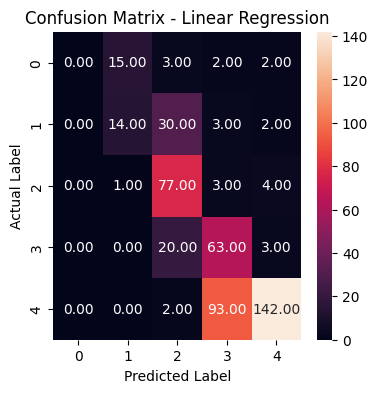

In [163]:
plt.figure(figsize=(4,4))
sns.heatmap(pd.DataFrame(conf_matrix_lin), annot=True, fmt=".2f")
plt.title("Confusion Matrix - Linear Regression")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.show()

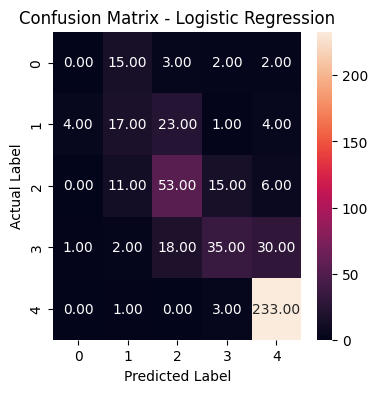

In [164]:
plt.figure(figsize=(4,4))
sns.heatmap(pd.DataFrame(conf_matrix_log), annot=True, fmt=".2f")
plt.title("Confusion Matrix - Logistic Regression")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.show()

3. Which model performs better in terms of accuracy? With logistic regression, how many 2s are predicted as 1s? And with Linear Regression?  (3 point)

- Logistic regression performs better in terms of accuracy based on the following:
    - Linear Regression Model Accuracy: ~0.618
    - Logistic Regression Model Accuracy: ~0.706

- Logistic regression - number of 2s predicted as 1s (based on confusion matrix): 11

# Part 3: Unsupervised learning

1. Using the **scaled** `x_train`, apply k-means with `k=5` and random_state=42`  (2 point)

In [198]:
from sklearn.cluster import KMeans

k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
y_train_pred_kmeans = kmeans.fit_predict(X_train_scaled)
y_train_pred_kmeans

/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


array([0, 1, 3, ..., 0, 3, 3], dtype=int32)

2. For each cluster, compute how many students are assigned to it  (3 point)

Hint: you can use `np.unique()` with argument `return_counts=True`

In [196]:
clusters, counts = np.unique(y_train_pred_kmeans, return_counts=True)

for i in range(len(clusters)):
    print(f"Cluster: {clusters[i]}, Count: {counts[i]}")


Cluster: 0, Count: 583
Cluster: 1, Count: 427
Cluster: 2, Count: 244
Cluster: 3, Count: 392
Cluster: 4, Count: 267


3. For the cluster with more samples assigned to it, display a bar plot with the values of `GradeClass` of the samples assigned to that cluster  (4 point)

In [205]:
bar_plot_df = pd.DataFrame({
    "GradeClass": y_train["GradeClass"],
    "Cluster": y_train_pred_kmeans
})

bar_plot_df = bar_plot_df[bar_plot_df["Cluster"]==0]
bar_plot_df.head()

,GradeClass,Cluster
642,4.0,0
1455,1.0,0
2221,1.0,0
554,1.0,0
668,2.0,0


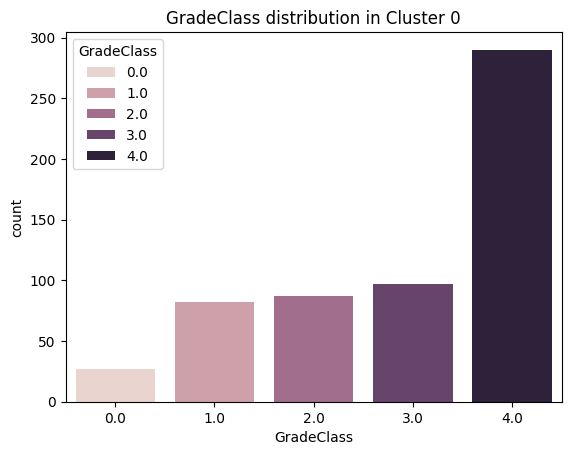

In [213]:
sns.countplot(data=bar_plot_df, x="GradeClass", hue="GradeClass")
plt.title(f"GradeClass distribution in Cluster {largest_cluster}")
plt.show()

4. Apply PCA with K=2 (i.e., 2 principal components) to `x_train_scaled`, then use the new projection to plot the data in 2 dimensions, coloring each point by its cluster assignment  (5 point)

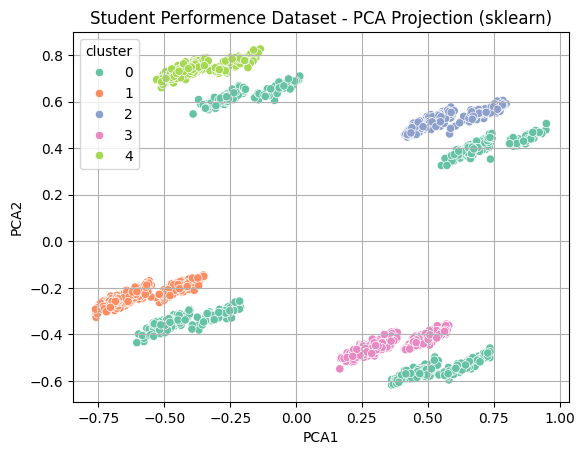

In [ ]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_train_scaled)
df_pca = pd.DataFrame({
    "PCA1":X_pca[:, 0],
    "PCA2":X_pca[:, 1],
    "cluster":y_train_pred_kmeans
})

import seaborn as sns 
sns.scatterplot(data=df_pca, x="PCA1", y="PCA2", hue="cluster", palette="Set2")
plt.title("Student Performence Dataset - PCA Projection (sklearn)")
plt.grid(True)
plt.show()